<a href="https://colab.research.google.com/github/saurabhsen848/Generative-AI_Assignment/blob/main/ASSIGNMENT_8_GEN_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
transform = transforms.ToTensor()
train_data = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_data = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader = DataLoader(test_data, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.48MB/s]


In [3]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.fc_mu = nn.Linear(128, 2)
        self.fc_logvar = nn.Linear(128, 2)
        self.fc2 = nn.Linear(2, 128)
        self.fc3 = nn.Linear(128, 784)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def decode(self, z):
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        std = torch.exp(0.5 * logvar)
        z = mu + std * torch.randn_like(std)
        return self.decode(z), mu, logvar

model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [4]:
recon_losses = []
kl_losses = []

for epoch in range(20):
    total_recon, total_kl = 0, 0
    for x, _ in train_loader:
        x = x.view(x.size(0), -1).to(device)

        recon, mu, logvar = model(x)
        recon_loss = F.binary_cross_entropy(recon, x, reduction="sum")
        kl_loss = -0.5 * torch.sum(1 + logvar - mu**2 - logvar.exp())
        loss = recon_loss + kl_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_recon += recon_loss.item()
        total_kl += kl_loss.item()

    recon_losses.append(total_recon / len(train_data))
    kl_losses.append(total_kl / len(train_data))
    print(f"Epoch {epoch+1}: Recon Loss = {recon_losses[-1]:.2f}, KL Loss = {kl_losses[-1]:.2f}")

Epoch 1: Recon Loss = 199.50, KL Loss = 8.25
Epoch 2: Recon Loss = 170.26, KL Loss = 5.59
Epoch 3: Recon Loss = 164.18, KL Loss = 5.42
Epoch 4: Recon Loss = 161.16, KL Loss = 5.41
Epoch 5: Recon Loss = 159.39, KL Loss = 5.42
Epoch 6: Recon Loss = 157.99, KL Loss = 5.46
Epoch 7: Recon Loss = 156.85, KL Loss = 5.51
Epoch 8: Recon Loss = 155.85, KL Loss = 5.54
Epoch 9: Recon Loss = 154.98, KL Loss = 5.57
Epoch 10: Recon Loss = 154.19, KL Loss = 5.59
Epoch 11: Recon Loss = 153.49, KL Loss = 5.64
Epoch 12: Recon Loss = 152.86, KL Loss = 5.66
Epoch 13: Recon Loss = 152.30, KL Loss = 5.69
Epoch 14: Recon Loss = 151.78, KL Loss = 5.71
Epoch 15: Recon Loss = 151.34, KL Loss = 5.72
Epoch 16: Recon Loss = 150.87, KL Loss = 5.75
Epoch 17: Recon Loss = 150.50, KL Loss = 5.78
Epoch 18: Recon Loss = 150.13, KL Loss = 5.81
Epoch 19: Recon Loss = 149.79, KL Loss = 5.83
Epoch 20: Recon Loss = 149.44, KL Loss = 5.85


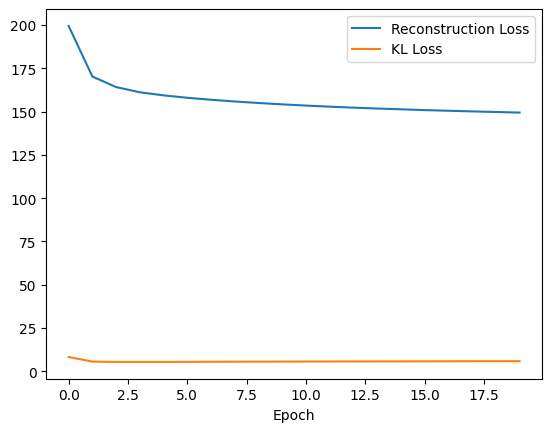

In [5]:
plt.plot(recon_losses, label="Reconstruction Loss")
plt.plot(kl_losses, label="KL Loss")
plt.xlabel("Epoch")
plt.legend()
plt.show()

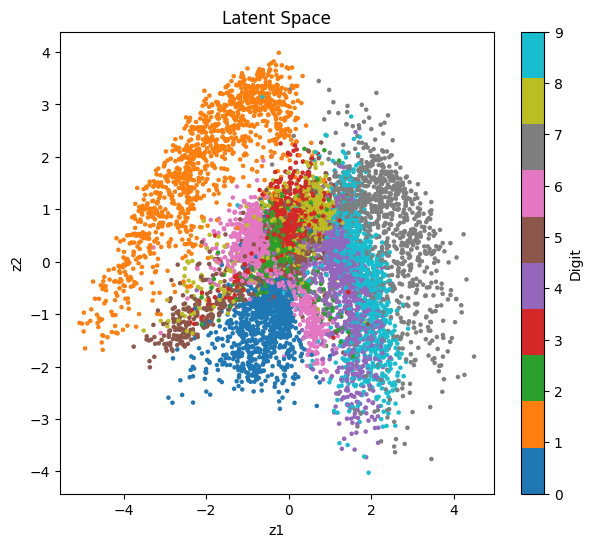

In [6]:
model.eval()
points, labels = [], []

with torch.no_grad():
    for x, y in test_loader:
        x = x.view(x.size(0), -1).to(device)
        mu, _ = model.encode(x)
        points.append(mu.cpu().numpy())
        labels.append(y.numpy())

points = np.concatenate(points)
labels = np.concatenate(labels)

plt.figure(figsize=(7, 6))
plt.scatter(points[:, 0], points[:, 1], c=labels, cmap="tab10", s=5)
plt.colorbar(label="Digit")
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("Latent Space")
plt.show()

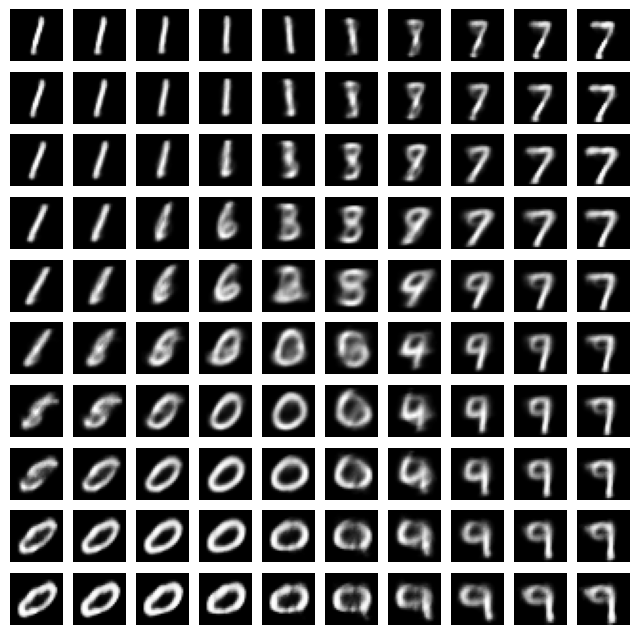

In [7]:
n = 10
grid = np.linspace(-3, 3, n)

fig, axes = plt.subplots(n, n, figsize=(8, 8))
with torch.no_grad():
    for i, y in enumerate(reversed(grid)):
        for j, x in enumerate(grid):
            z = torch.tensor([[x, y]], dtype=torch.float32).to(device)
            img = model.decode(z).cpu().numpy().reshape(28, 28)
            axes[i, j].imshow(img, cmap="gray")
            axes[i, j].axis("off")
plt.show()